Completed 5000 runs -- 5000 succeeded, 0 failed.
Clustering complete. Cluster sizes:
  Cluster 0: 4082 runs
  Cluster 1: 358 runs
  Cluster 2: 560 runs
         Natural  Bacterial  Viral  Grazing
cluster                                    
0          0.068      0.018  0.914      0.0
1          0.082      0.717  0.201      0.0
2          0.068      0.024  0.908      0.0
Cluster sizes after sorting:
  Cluster 0: 560 runs
  Cluster 1: 358 runs
  Cluster 2: 4082 runs
Cluster 0
  rho=3.7e-14
  phi_V=3.8e-08
  beta_V=4.7e+02
  Gmax=4.1e+00
  k_m=7.6e+03

Cluster 1
  rho=1.6e-14
  phi_V=2.4e-09
  beta_V=7.1e+02
  Gmax=3.6e+00
  k_m=2.4e+04

Cluster 2
  rho=4.2e-14
  phi_V=5.1e-08
  beta_V=2.9e+02
  Gmax=3.6e+00
  k_m=4.6e+04



/var/folders/mp/cspgvq_d2h13_l03bp7hsr0r0000gn/T/ipykernel_36603/991019145.py:259: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax_top.set_ylim(0, 5e6)


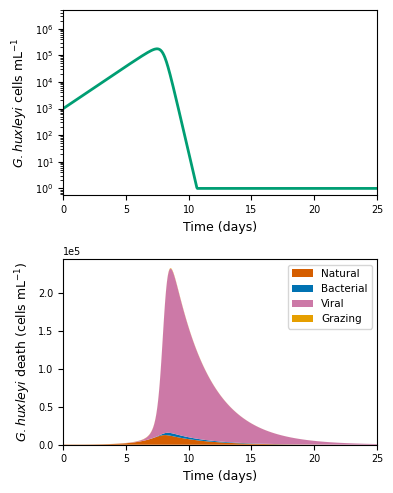

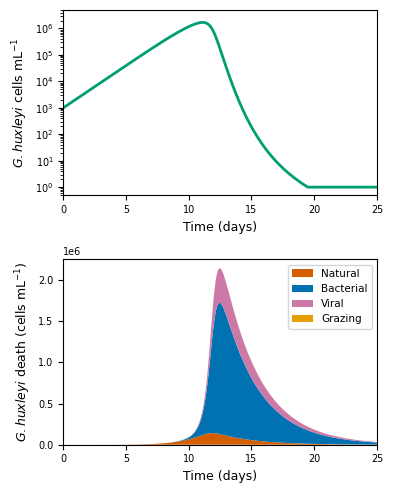

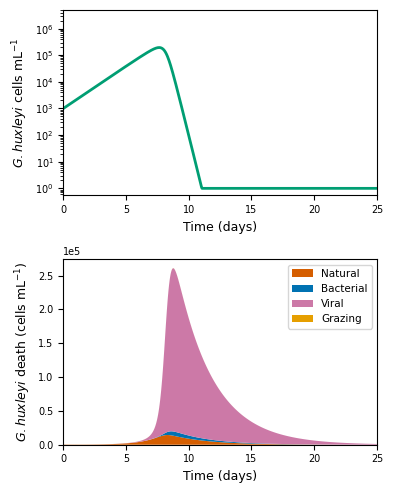

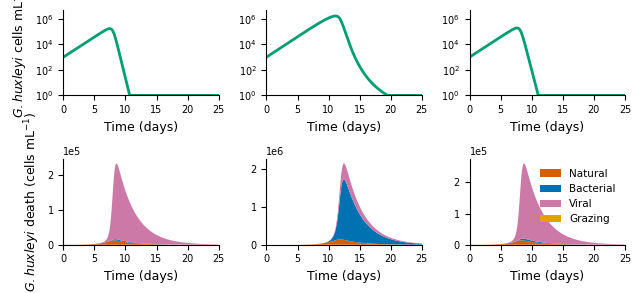

In [1]:
# %% [markdown]
# # *Gephyrocapsa huxleyi* Ecosystem Model
#
# ## Figures for Jackson Page-Roth's Master's Thesis
#
# ### Parameters:
# | Symbol | Description |
# |--------|-------------|
# | **P** | *E. huxleyi* concentration (cells mL-1) |
# | **B** | *Sulfitobacter* D7 (bacteria) concentration (cells mL-1) |
# | **V** | Virus (EhV) concentration (particles mL-1) |
# | **Z** | Zooplankton / ciliate concentration (cells mL-1) |
# | **D** | Dead *E. huxleyi* cells (cells mL-1), lumped pool driving phi_B |
# | **D_nat, D_bact, D_vir, D_zoop** | Dead *E. huxleyi* cells (cells mL-1), by pathway -- bookkeeping only, do not feed back into the dynamics |
# | **mu_P, mu_B** | Growth rates (day-1) |
# | **k_P, k_B** | Carrying capacities |
# | **phi_V** | Viral virulence (mL cell-1 day-1) |
# | **beta_V** | Viral burst size |
# | **rho** | Dead-cell scaling of bacterial phi_B (mL cell-1) |
# | **Gmax, k_m** | Grazing parameters |
# | **delta_P** | *E. hux* natural death rate (day-1) |
# | **lambda_D** | Dead cell organic dissolution rate (day-1) |
#
# This notebook covers the ecosystem-model experiment: the multi-mortality-pathway
# model (natural death, bacterial lysis, viral lysis, grazing), the Latin-Hypercube
# parameter sweep + clustering (Figure 5), and the grazing-inhibition-by-metabolites
# variant kept as a labeled alternate branch.
#
# ODE core (P, D, B, V, Z) matches `MCMC_whole_env.py`'s `general_case` exactly --
# lumped `D` drives `phi_B = rho * D` and feeds back into growth/mortality. The
# per-pathway `D_nat/D_bact/D_vir/D_zoop` states are appended purely as
# bookkeeping accumulators (same decay rate `lambda_D`, no feedback) so death
# fractionation can still be computed and plotted without complicating the core
# dynamics.

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp
from scipy.stats.qmc import LatinHypercube, scale
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
import os

warnings.filterwarnings('ignore', category=RuntimeWarning)

# %%
# -- Global settings ----------------------------------------------------------
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "lines.linewidth": 1.5,
    "lines.markersize": 7.5,
    "legend.fontsize": 7.5,
})
colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']

# %% [markdown]
# # Figure 5 — Ecosystem Model (base grazing saturation)

# %%
## Cell -- ODE system (9 states: P, D, B, V, Z, D_nat, D_bact, D_vir, D_zoop) ##

params_eco = {
    'P0':       1.0000e+03, 'mu_P':     7.918218e-01, 'k_P':      5.382034e+06, 'delta_P':  5.294857e-02,
    'B0':       1.0000e+04, 'mu_B':     8.503184e-01, 'k_B':      1.022709e+08, 'beta_B':   3.384754e+00, 'rho':      5.113946e-15,
    'V0':       1.0000e+05, 'phi_V':    7.0737e-08, 'beta_V':   3.0701e+02,
    'Z0':       1.0000e+01, 'Gmax':     4.3600e-01, 'k_m':      1.7036e+01,
    'D0':       4.0000e+02, 'lambda_D': 3.409695e-01, 'theta_Z':  1.1400e-01
}

# params_eco = {
#     'P0':       1.0000e+03, 'mu_P':     4.7800e-01, 'k_P':      8.9137e+06, 'delta_P':  6.5000e-02,
#     'B0':       1.0000e+04, 'mu_B':     6.1400e-01, 'k_B':      5.2633e+06, 'beta_B':   2.8718e+01, 'rho':      9.0004e-14,
#     'V0':       1.0000e+05, 'phi_V':    7.0737e-08, 'beta_V':   3.0701e+02,
#     'Z0':       1.0000e+01, 'Gmax':     4.3600e-01, 'k_m':      1.7036e+01,
#     'D0':       4.0000e+02, 'lambda_D': 3.1800e-01, 'theta_Z':  1.1400e-01
# }
T_END_ECO   = 25.0
t_dense_eco = np.linspace(0, T_END_ECO, 600)

# order params dict -> positional array must unpack exactly like this everywhere
PARAM_ORDER_ECO = ['mu_P', 'k_P', 'delta_P', 'mu_B', 'k_B', 'beta_B', 'rho', 'lambda_D',
                    'beta_V', 'phi_V', 'Gmax', 'k_m', 'theta_Z']


def ode_rhs_eco_base(t, y, params):
    P, D, B, V, Z, D_nat, D_bact, D_vir, D_zoop = np.maximum(y, 0.0)
    mu_P, k_P, delta_P, mu_B, k_B, beta_B, rho, lambda_D, \
        beta_V, phi_V, Gmax, k_m, theta_Z = params

    phi_B = rho * D
    graz  = Gmax * P / (k_m + P) * Z

    dPdt = mu_P * P * (1 - P / k_P) - delta_P * P - phi_B * P * B - phi_V * P * V - graz
    dDdt = delta_P * P + phi_B * P * B + phi_V * P * V - lambda_D * D
    dBdt = mu_B * B * (1 - B / k_B) + beta_B * phi_B * P * B
    dVdt = beta_V * phi_V * P * V
    dZdt = theta_Z * graz

    # -- death fractionation bookkeeping only -- no feedback into P/B/V/Z/D --
    dD_nat  = delta_P * P    - lambda_D * D_nat
    dD_bact = phi_B * P * B  - lambda_D * D_bact
    dD_vir  = phi_V * P * V  - lambda_D * D_vir
    dD_zoop = graz           - lambda_D * D_zoop

    return [dPdt, dDdt, dBdt, dVdt, dZdt, dD_nat, dD_bact, dD_vir, dD_zoop]


def run_ode_eco(p, t_out, rhs=ode_rhs_eco_base):
    params = [p[name] for name in PARAM_ORDER_ECO]
    y0 = [p['P0'], p['D0'], p['B0'], p['V0'], p['Z0'], p['D0'], 0.0, 0.0, 0.0]
    t_eval = np.unique(t_out)
    t_span = (0.0, float(t_eval.max()) + 0.1)
    for method in ('RK45', 'Radau'):
        try:
            sol = solve_ivp(rhs, t_span, y0, method=method, t_eval=t_eval,
                            args=(params,), rtol=1e-6, atol=1e-9)
            if sol.success and np.all(np.isfinite(sol.y)):
                interp = lambda row: np.interp(t_out, t_eval, row)
                return [np.maximum(interp(sol.y[i]), 1.0) for i in range(9)]
        except Exception:
            continue
    return None

# %%
N_SAMPLES = 5000
PARAM_RANGES = {
    'rho':    (1e-15, 5e-14),
    'phi_V':  (1e-10, 1e-7),
    'beta_V': (200,   800),
    'Gmax':   (0.4,   5),
    'k_m':    (4800,     48000),
}
PARAM_NAMES = list(PARAM_RANGES.keys())
N_PARAMS    = len(PARAM_NAMES)

sampler   = LatinHypercube(d=N_PARAMS, seed=42)
unit_cube = sampler.random(n=N_SAMPLES)
lo = [PARAM_RANGES[k][0] for k in PARAM_NAMES]
hi = [PARAM_RANGES[k][1] for k in PARAM_NAMES]
samples = scale(unit_cube, lo, hi)

results_sweep = []
params_sweep  = []
for row in samples:
    p = {**params_eco}
    for name, val in zip(PARAM_NAMES, row):
        p[name] = val
    res = run_ode_eco(p, t_dense_eco)
    results_sweep.append(res)
    params_sweep.append(p)

n_ok = sum(r is not None for r in results_sweep)
print(f'Completed {N_SAMPLES} runs -- {n_ok} succeeded, {N_SAMPLES - n_ok} failed.')

# %%
N_CLUSTERS = 3

features  = []
valid_idx = []

for i, res in enumerate(results_sweep):
    if res is None: continue
    P_t, D_t, B_t, V_t, Z_t, D_nat, D_bact, D_vir, D_zoop = res
    p = params_sweep[i]
    phi_B_t = p['rho'] * D_t
    graz_t  = p['Gmax'] * P_t / (p['k_m'] + P_t) * Z_t
    flux_nat  = p['delta_P'] * P_t
    flux_bact = phi_B_t      * P_t * B_t
    flux_vir  = p['phi_V']   * P_t * V_t
    flux_zoop = p['theta_Z'] * graz_t
    total_sum = (np.sum(flux_nat) + np.sum(flux_bact) +
                 np.sum(flux_vir) + np.sum(flux_zoop) + 1e-30)

    frac_nat  = float(np.sum(flux_nat)  / total_sum)
    frac_bact = float(np.sum(flux_bact) / total_sum)
    frac_vir  = float(np.sum(flux_vir)  / total_sum)
    frac_zoop = float(np.sum(flux_zoop) / total_sum)

    features.append([frac_nat, frac_bact, frac_vir, frac_zoop])
    valid_idx.append(i)

features  = np.array(features)
valid_idx = np.array(valid_idx)

scaler      = StandardScaler()
feat_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
labels = kmeans.fit_predict(feat_scaled)

print('Clustering complete. Cluster sizes:')
for k in range(N_CLUSTERS):
    print(f'  Cluster {k}: {(labels == k).sum()} runs')

frac_df = pd.DataFrame(features, columns=['Natural', 'Bacterial', 'Viral', 'Grazing'])
frac_df['cluster'] = labels


# %%
representatives = {}
for k in range(N_CLUSTERS):
    mask     = labels == k
    centroid = kmeans.cluster_centers_[k]
    dists    = np.linalg.norm(feat_scaled[mask] - centroid, axis=1)
    local_i  = np.argmin(dists)
    global_i = valid_idx[np.where(mask)[0][local_i]]
    representatives[k] = global_i

# -- Sort clusters by grazing fraction descending after k-means ---------------
cluster_means = frac_df.groupby('cluster').mean()
sort_order    = cluster_means['Grazing'].argsort()[::-1].values
# sort_order[0] = old cluster label that had highest grazing

label_map = {old: new for new, old in enumerate(sort_order)}

# Remap labels array and frac_df
labels            = np.array([label_map[l] for l in labels])
frac_df['cluster'] = labels

# Remap representatives dict
representatives = {label_map[old_k]: idx
                   for old_k, idx in representatives.items()}

print(frac_df.groupby('cluster').mean().round(3).to_string())

print('Cluster sizes after sorting:')
for k in range(N_CLUSTERS):
    print(f'  Cluster {k}: {(labels == k).sum()} runs')

for k in range(N_CLUSTERS):
    p = params_sweep[representatives[k]]
    print(f'Cluster {k}')
    print('\n'.join([f'  {n}={p[n]:.1e}' for n in PARAM_NAMES]))
    print()

# %%
SUBFIG_LABELS = 'abcdefghij'

for k in range(N_CLUSTERS):
    i   = representatives[k]
    res = results_sweep[i]
    p   = params_sweep[i]
    P_t, D_t, B_t, V_t, Z_t, D_nat, D_bact, D_vir, D_zoop = res

    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(4, 5))

    ax_top.plot(t_dense_eco, P_t, color=colors[2], lw=2)
    ax_top.set_yscale('log')
    ax_top.set_xlabel('Time (days)')
    ax_top.set_ylabel(r'$\it{G. huxleyi}$ cells mL$^{-1}$')
    ax_top.set_xlim(0, T_END_ECO)
    ax_top.set_ylim(0, 5e6)

    ax_bot.stackplot(
        t_dense_eco, D_nat, D_bact, D_vir, D_zoop,
        labels=['Natural', 'Bacterial', 'Viral', 'Grazing'],
        colors=[colors[5], colors[4], colors[6], colors[0]],
    )
    ax_bot.set_xlabel('Time (days)')
    ax_bot.set_ylabel(r'$\it{G. huxleyi}$ death (cells mL$^{-1}$)')
    ax_bot.set_xlim(0, T_END_ECO)
    # ax_bot.set_yscale('log')
    ax_bot.ticklabel_format(style='sci', scilimits=(0, 0), axis='y')
    ax_bot.legend(loc='best')

    plt.tight_layout()
    fname = f'figures/fig05{SUBFIG_LABELS[k]}.pdf'
    # plt.savefig(fname, dpi=600, bbox_inches='tight')
    # print(f'Saved: {fname}')
    plt.show()

# %%
fig, axes = plt.subplots(2, N_CLUSTERS, figsize=(2.16 * N_CLUSTERS, 3))

for k in range(N_CLUSTERS):
    i   = representatives[k]
    res = results_sweep[i]
    p   = params_sweep[i]
    P_t, D_t, B_t, V_t, Z_t, D_nat, D_bact, D_vir, D_zoop = res

    ax_top = axes[0, k]
    ax_bot = axes[1, k]

    # -- Top: P trajectory ------------------------------------------------------
    ax_top.plot(t_dense_eco, P_t, color=colors[2], lw=2)
    ax_top.set_yscale('log')
    ax_top.set_xlabel('Time (days)')
    ax_top.set_xlim(0, T_END_ECO)
    ax_top.set_ylim(1, 5e6)
    if k == 0:
        ax_top.set_ylabel(r'$\it{G. huxleyi}$ cells mL$^{-1}$')

    # -- Bottom: stacked dead cells -----------------------------------------------
    ax_bot.stackplot(
        t_dense_eco, D_nat, D_bact, D_vir, D_zoop,
        labels=['Natural', 'Bacterial', 'Viral', 'Grazing'],
        colors=[colors[5], colors[4], colors[6], colors[0]],
    )
    ax_bot.set_xlabel('Time (days)')
    ax_bot.set_xlim(0, T_END_ECO)
    # ax_bot.set_yscale('log')
    # ax_bot.set_ylim(0, 3e7)
    ax_bot.ticklabel_format(style='sci', scilimits=(0, 0), axis='y')
    if k == 0:
        ax_bot.set_ylabel(r'$\it{G. huxleyi}$ death (cells mL$^{-1}$)')
    if k == N_CLUSTERS-1:
        ax_bot.legend(loc='best', frameon=False)

sns.despine()
plt.tight_layout()
plt.savefig('figures/fig05.pdf', dpi=600, bbox_inches='tight')
plt.show()


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp
from scipy.stats.qmc import LatinHypercube, scale
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
import os

warnings.filterwarnings('ignore', category=RuntimeWarning)

In [3]:
colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']

# Figure 5 — Ecosystem Model

                 mean           sd       hdi_3%       hdi_97%   mcse_mean  \
mu_P            0.478        0.040        0.407  5.440000e-01       0.008   
k_P       8913678.663  4285325.789  2855652.686  1.697886e+07  977842.312   
delta_P         0.065        0.035        0.020  1.170000e-01       0.009   
mu_B            0.614        0.145        0.378  9.050000e-01       0.023   
k_B       5263333.308  2069180.161  4066510.552  6.112046e+06  316714.946   
beta_B         28.718       13.530       10.221  5.404600e+01       3.623   
rho             0.000        0.000        0.000  0.000000e+00       0.000   
lambda_D        0.318        0.130        0.124  5.660000e-01       0.023   
beta_V        307.007       79.905      172.943  4.573780e+02      11.097   
phi_V           0.000        0.000        0.000  0.000000e+00       0.000   
Gmax            0.436        0.137        0.212  7.020000e-01       0.026   
k_m            17.036       10.922        3.503  3.680400e+01       3.392   
theta_Z         0.114        0.034        0.055  1.760000e-01       0.002   

             mcse_sd  ess_bulk  ess_tail  r_hat  
mu_P           0.006      34.0      32.0   1.08  
k_P       702219.954      24.0      40.0   1.11  
delta_P        0.007      22.0      15.0   1.13  
mu_B           0.016      37.0      62.0   1.08  
k_B       225499.675      40.0      48.0   1.06  
beta_B         2.617      16.0      43.0   1.17  
rho            0.000      62.0      22.0   1.05  
lambda_D       0.016      30.0    1189.0   1.09  
beta_V         7.891      51.0     292.0   1.05  
phi_V          0.000      41.0      73.0   1.07  
Gmax           0.019      34.0      50.0   1.08  
k_m            2.470      13.0      14.0   1.22  
theta_Z        0.002     194.0     199.0   1.01  
               mean            sd        hdi_3%       hdi_97%     mcse_mean  \
rho    9.000419e-14  4.572813e-14  2.634399e-14  1.737916e-13  8.300080e-15   
phi_V  7.073742e-08  1.126732e-08  4.984956e-08  9.169943e-08  1.733468e-09  

In [4]:
params_eco = {
    'P0':       1.0000e+03, 'mu_P':     0.478, 'k_P':      8.9e6, 'delta_P':  0.065,
    'B0':       1.0000e+04, 'mu_B':     0.614, 'k_B':      5.3e06, 'beta_B':   28.7, 'rho':      9.0e-14,
    'V0':       1.0000e+05, 'phi_V':    7.073742e-08, 'k_V':      1.0000e+10, 'beta_V':   7.891,
    'Z0':       1.0000e+01, 'Gmax':     0.019, 'k_Z':      4.0000e+06, 'k_m':      2.470,
    'D0':       4.0000e+02, 'lambda_D': 2.9388e-01, 'theta_Z':  0.1
}
T_END_ECO   = 15.0
t_dense_eco = np.linspace(0, T_END_ECO, 600)


def ode_rhs_eco(t, y, p):
    P, B, V, Z, D_nat, D_bact, D_vir, D_zoop = np.maximum(y, 0.0)
    phi_B = p['rho'] * (D_nat + D_bact + D_vir + D_zoop*0)
    phi_V = p['phi_V']
    graz  = p['Gmax'] * P * (1-Z/p['k_Z']) / (p['k_m'] + P) * Z
    dP      = (p['mu_P'] * P * (1 - P / p['k_P']) - p['delta_P'] * P
               - phi_B * P * B - phi_V * P * V * (1-V/p['k_V']) - graz)
    dB      = p['mu_B'] * B * (1 - B / p['k_B']) + p['beta_B'] * phi_B * P * B
    dV      = p['beta_V'] * phi_V * P * V * (1-V/p['k_V'])
    dZ      = p['theta_Z'] * graz
    dD_nat  = p['delta_P'] * P  - p['lambda_D'] * D_nat
    dD_bact = phi_B * P * B     - p['lambda_D'] * D_bact
    dD_vir  = phi_V * P * V     - p['lambda_D'] * D_vir
    dD_zoop = graz              - p['lambda_D'] * D_zoop
    return [dP, dB, dV, dZ, dD_nat, dD_bact, dD_vir, dD_zoop]


def run_ode_eco(p, t_out):
    y0     = [p['P0'], p['B0'], p['V0'], p['Z0'], p['D0'], 0.0, 0.0, 0.0]
    t_eval = np.unique(t_out)
    t_span = (0.0, float(t_eval.max()) + 0.1)
    for method in ('RK45', 'Radau'):
        try:
            sol = solve_ivp(lambda t, y: ode_rhs_eco(t, y, p),
                            t_span, y0, method=method, t_eval=t_eval,
                            rtol=1e-6, atol=1e-9)
            if sol.success and np.all(np.isfinite(sol.y)):
                interp = lambda row: np.interp(t_out, t_eval, row)
                return [np.maximum(interp(sol.y[i]), 1.0) for i in range(8)]
        except Exception:
            continue
    return None

In [5]:
N_SAMPLES = 5000
PARAM_RANGES = {
    'rho':    (1e-14, 1e-13),
    'phi_V':  (1e-10, 5e-8),
    'beta_V': (200,   800),
    'Gmax':   (0.4,   5),
    'k_m':    (4800,     48000),
}
PARAM_NAMES = list(PARAM_RANGES.keys())
N_PARAMS    = len(PARAM_NAMES)

sampler   = LatinHypercube(d=N_PARAMS, seed=42)
unit_cube = sampler.random(n=N_SAMPLES)
lo = [PARAM_RANGES[k][0] for k in PARAM_NAMES]
hi = [PARAM_RANGES[k][1] for k in PARAM_NAMES]
samples = scale(unit_cube, lo, hi)

results_sweep = []
params_sweep  = []
for row in samples:
    p = {**params_eco}
    for name, val in zip(PARAM_NAMES, row):
        p[name] = val
    res = run_ode_eco(p, t_dense_eco)
    results_sweep.append(res)
    params_sweep.append(p)

n_ok = sum(r is not None for r in results_sweep)
print(f'Completed {N_SAMPLES} runs -- {n_ok} succeeded, {N_SAMPLES - n_ok} failed.')

Completed 5000 runs -- 5000 succeeded, 0 failed.


In [6]:
N_CLUSTERS = 3

features  = []
valid_idx = []

for i, res in enumerate(results_sweep):
    if res is None: continue
    P_t, B_t, V_t, Z_t, D_nat, D_bact, D_vir, D_zoop = res
    p = params_sweep[i]
    phi_B_t = p['rho'] * (D_nat + D_bact + D_vir + D_zoop)
    graz_t  = p['Gmax'] * P_t / (p['k_m'] + P_t) * Z_t
    flux_nat  = p['delta_P'] * P_t
    flux_bact = phi_B_t      * P_t * B_t
    flux_vir  = p['phi_V']   * P_t * V_t
    flux_zoop = p['theta_Z'] * graz_t
    total_sum = (np.sum(flux_nat) + np.sum(flux_bact) +
                 np.sum(flux_vir) + np.sum(flux_zoop) + 1e-30)

    frac_nat  = float(np.sum(flux_nat)  / total_sum)
    frac_bact = float(np.sum(flux_bact) / total_sum)
    frac_vir  = float(np.sum(flux_vir)  / total_sum)
    frac_zoop = float(np.sum(flux_zoop) / total_sum)

    features.append([frac_nat, frac_bact, frac_vir, frac_zoop])
    valid_idx.append(i)
    
features  = np.array(features)
valid_idx = np.array(valid_idx)

scaler      = StandardScaler()
feat_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
labels = kmeans.fit_predict(feat_scaled)

print('Clustering complete. Cluster sizes:')
for k in range(N_CLUSTERS):
    print(f'  Cluster {k}: {(labels == k).sum()} runs')

frac_df = pd.DataFrame(features, columns=['Natural', 'Bacterial', 'Viral', 'Grazing'])
frac_df['cluster'] = labels


Clustering complete. Cluster sizes:
  Cluster 0: 3728 runs
  Cluster 1: 1157 runs
  Cluster 2: 115 runs


In [7]:
representatives = {}
for k in range(N_CLUSTERS):
    mask     = labels == k
    centroid = kmeans.cluster_centers_[k]
    dists    = np.linalg.norm(feat_scaled[mask] - centroid, axis=1)
    local_i  = np.argmin(dists)
    global_i = valid_idx[np.where(mask)[0][local_i]]
    representatives[k] = global_i

# -- Sort clusters by grazing fraction descending after k-means ---------------
cluster_means = frac_df.groupby('cluster').mean()
sort_order    = cluster_means['Grazing'].argsort()[::-1].values  
# sort_order[0] = old cluster label that had highest grazing

label_map = {old: new for new, old in enumerate(sort_order)}

# Remap labels array and frac_df
labels            = np.array([label_map[l] for l in labels])
frac_df['cluster'] = labels

# Remap representatives dict
representatives = {label_map[old_k]: idx
                   for old_k, idx in representatives.items()}

print(frac_df.groupby('cluster').mean().round(3).to_string())

print('Cluster sizes after sorting:')
for k in range(N_CLUSTERS):
    print(f'  Cluster {k}: {(labels == k).sum()} runs')
    
for k in range(N_CLUSTERS):
    p = params_sweep[representatives[k]]
    print(f'Cluster {k}')
    print('\n'.join([f'  {n}={p[n]:.1e}' for n in PARAM_NAMES]))
    print()

         Natural  Bacterial  Viral  Grazing
cluster                                    
0          0.787      0.067  0.138    0.007
1          0.781      0.079  0.139    0.001
2          0.164      0.020  0.816    0.000
Cluster sizes after sorting:
  Cluster 0: 115 runs
  Cluster 1: 1157 runs
  Cluster 2: 3728 runs
Cluster 0
  rho=4.4e-14
  phi_V=1.1e-08
  beta_V=2.8e+02
  Gmax=3.9e+00
  k_m=5.5e+03

Cluster 1
  rho=5.2e-14
  phi_V=1.1e-08
  beta_V=3.1e+02
  Gmax=3.5e+00
  k_m=3.8e+04

Cluster 2
  rho=3.7e-14
  phi_V=1.8e-08
  beta_V=5.0e+02
  Gmax=4.3e+00
  k_m=3.5e+04



/var/folders/mp/cspgvq_d2h13_l03bp7hsr0r0000gn/T/ipykernel_36603/2044396356.py:16: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax_top.set_ylim(0, 5e6)


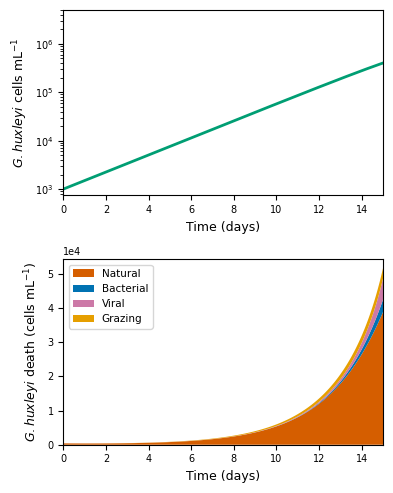

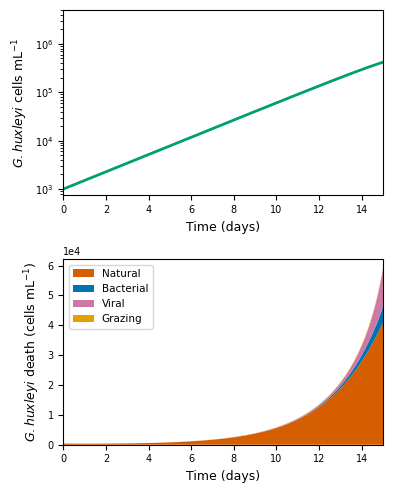

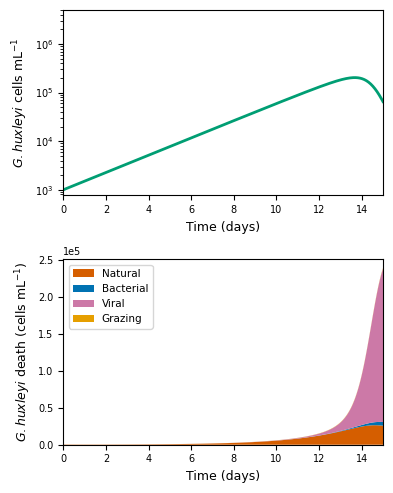

In [8]:
SUBFIG_LABELS = 'abcdefghij'

for k in range(N_CLUSTERS):
    i   = representatives[k]
    res = results_sweep[i]
    p   = params_sweep[i]
    P_t, B_t, V_t, Z_t, D_nat, D_bact, D_vir, D_zoop = res

    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(4, 5))

    ax_top.plot(t_dense_eco, P_t, color=colors[2], lw=2)
    ax_top.set_yscale('log')
    ax_top.set_xlabel('Time (days)')
    ax_top.set_ylabel(r'$\it{G. huxleyi}$ cells mL$^{-1}$')
    ax_top.set_xlim(0, T_END_ECO)
    ax_top.set_ylim(0, 5e6)

    ax_bot.stackplot(
        t_dense_eco, D_nat, D_bact, D_vir, D_zoop,
        labels=['Natural', 'Bacterial', 'Viral', 'Grazing'],
        colors=[colors[5], colors[4], colors[6], colors[0]],
    )
    ax_bot.set_xlabel('Time (days)')
    ax_bot.set_ylabel(r'$\it{G. huxleyi}$ death (cells mL$^{-1}$)')
    ax_bot.set_xlim(0, T_END_ECO)
    # ax_bot.set_yscale('log')
    ax_bot.ticklabel_format(style='sci', scilimits=(0, 0), axis='y')
    ax_bot.legend(loc='best')

    plt.tight_layout()
    fname = f'figures/fig05{SUBFIG_LABELS[k]}.pdf'
    # plt.savefig(fname, dpi=600, bbox_inches='tight')
    # print(f'Saved: {fname}')
    plt.show()

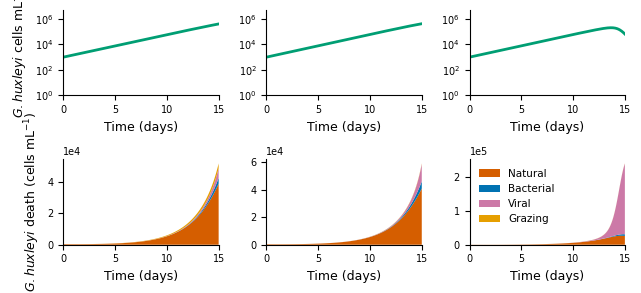

In [9]:
fig, axes = plt.subplots(2, N_CLUSTERS, figsize=(2.16 * N_CLUSTERS, 3))

for k in range(N_CLUSTERS):
    i   = representatives[k]
    res = results_sweep[i]
    p   = params_sweep[i]
    P_t, B_t, V_t, Z_t, D_nat, D_bact, D_vir, D_zoop = res

    ax_top = axes[0, k]
    ax_bot = axes[1, k]

    # -- Top: P trajectory ------------------------------------------------------
    ax_top.plot(t_dense_eco, P_t, color=colors[2], lw=2)
    ax_top.set_yscale('log')
    ax_top.set_xlabel('Time (days)')
    ax_top.set_xlim(0, T_END_ECO)
    ax_top.set_ylim(1, 5e6)
    if k == 0:
        ax_top.set_ylabel(r'$\it{G. huxleyi}$ cells mL$^{-1}$')

    # -- Bottom: stacked dead cells -----------------------------------------------
    ax_bot.stackplot(
        t_dense_eco, D_nat, D_bact, D_vir, D_zoop,
        labels=['Natural', 'Bacterial', 'Viral', 'Grazing'],
        colors=[colors[5], colors[4], colors[6], colors[0]],
    )
    ax_bot.set_xlabel('Time (days)')
    ax_bot.set_xlim(0, T_END_ECO)
    # ax_bot.set_yscale('log')
    # ax_bot.set_ylim(0, 3e7)
    ax_bot.ticklabel_format(style='sci', scilimits=(0, 0), axis='y')
    if k == 0:
        ax_bot.set_ylabel(r'$\it{G. huxleyi}$ death (cells mL$^{-1}$)')
    if k == N_CLUSTERS-1:
        ax_bot.legend(loc='best', frameon=False)

sns.despine()
plt.tight_layout()
plt.savefig('figures/fig05.pdf', dpi=600, bbox_inches='tight')
plt.show()
